# Modeling Environmental Determinants of Mental Wellbeing: A Data Science and Biostatistical Analysis of UK Local Authorities

## ntegrating Machine Learning, Clustering, and Hypothesis Testing on UK Population Data

# 1. Introduction

Mental wellbeing is a key component of population health and is influenced by environmental conditions such as access to green space. This project investigates the relationship between access to public green spaces and mental wellbeing across UK local authorities.

Two datasets from the UK Office for National Statistics (ONS) are used:

Personal wellbeing estimates (anxiety, happiness, life satisfaction)
Access to public green space indicators

This project combines data science techniques (regression, clustering) and biostatistical methods (hypothesis testing) to explore whether environmental exposure is associated with mental health outcomes.

# Dataset Links

1. Wellbeing Dataset

From UK Office for National Statistics

https://www.ons.gov.uk/filter-outputs/16ebb59b-f209-4b7f-a35a-d083f3e846d1

File name : wellbeing-local-authority-time-series-v4-filtered-2024-09-24T14-50-53Z.csv

2. Green Space Dataset

From UK Office for National Statistics

https://www.ons.gov.uk/peoplepopulationandcommunity/wellbeing/datasets/accesstopublicgreenspaceingreatbritain

Fine name: urben park.csv

## Data Sources and Justification

This project integrates two complementary datasets from the UK Office for National Statistics (ONS) to investigate the relationship between environmental exposure and mental wellbeing.

The first dataset, "Personal Wellbeing Estimates by Local Authority", provides self-reported measures of mental wellbeing, including anxiety, happiness, life satisfaction, and sense of worth. These variables serve as the primary outcome measures in the analysis.

The second dataset, "Access to Public Green Space in Great Britain", provides detailed information on environmental characteristics, including proximity to parks, number of green spaces, and total accessible green area. These variables represent potential explanatory factors influencing mental wellbeing.

The rationale for combining these datasets is to move beyond descriptive analysis of wellbeing and instead examine how external environmental conditions may contribute to variations in mental health outcomes. By merging both datasets at the local authority level, the analysis enables a more realistic and policy-relevant investigation of whether access to green space is associated with improved mental wellbeing.

This integrated approach reflects real-world data science practice, where multiple data sources are combined to uncover meaningful relationships between environmental and health-related variables.

# 2. Objectives:

* Transform and clean real-world datasets
* Integrate multiple data sources
* Model mental health outcomes
* Identify patterns via clustering
* Perform statistical hypothesis testing

# 3. Data Acquisition

In [31]:
# Load datasets
wellbeing = pd.read_csv("wellbeing-local-authority-time-series-v4-filtered-2024-09-24T14-50-53Z.csv")
parks = pd.read_csv("urben park.csv")

In [32]:
print("Wellbeing shape:", wellbeing.shape) 
print("Parks shape:", parks.shape) 
wellbeing.head() 

Wellbeing shape: (2200, 12)
Parks shape: (527, 31)


,v4_3,Data marking,Lower limit,Upper limit,yyyy-yy,Time,administrative-geography,Geography,measure-of-wellbeing,MeasureOfWellbeing,wellbeing-estimate,Estimate
0,50.68,NaN,49.48,51.89,2014-15,2014-15,E12000001,North East,life-satisfaction,Life satisfaction,good,Good
1,30.41,NaN,29.20,31.62,2017-18,2017-18,E12000001,North East,life-satisfaction,Life satisfaction,very-good,Very good
2,25.30,NaN,23.84,26.76,2020-21,2020-21,E12000001,North East,life-satisfaction,Life satisfaction,very-good,Very good
3,6.32,NaN,5.75,6.90,2013-14,2013-14,E12000001,North East,life-satisfaction,Life satisfaction,poor,Poor
4,13.98,NaN,13.09,14.88,2017-18,2017-18,E12000001,North East,life-satisfaction,Life satisfaction,fair,Fair


In [34]:
parks.head()

,Country code,Country name,Region code,Region name,LAD code,LAD name,Google sub region 1,Google sub region 2,Average distance to nearest park or public garden or playing field (m),Median distance to nearest park or public garden or playing field (m),...,Average garden size for flats in built up area,Number of houses within built up area,Number of houses in built up area with gardens,Average garden size for houses in built up area,Average percent change in mobility to parks from baseline during lockdown period,Average percent change in mobility to parks from baseline during post-lockdown period,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30
0,E92000001,England,E12000001,North East,E06000001,Hartlepool,Hartlepool,NaN,619.23,587.01,...,231.96,37126.0,36638.0,177.96,-49.78,NaN,NaN,NaN,NaN,NaN
1,E92000001,England,E12000001,North East,E06000002,Middlesbrough,Middlesbrough,NaN,744.03,557.88,...,191.01,54102.0,53596.0,177.67,-26.58,15.82,NaN,NaN,NaN,NaN
2,E92000001,England,E12000001,North East,E06000003,Redcar and Cleveland,Redcar and Cleveland,NaN,774.18,616.89,...,188.35,55912.0,54529.0,194.63,-3.38,68.69,NaN,NaN,NaN,NaN
3,E92000001,England,E12000001,North East,E06000004,Stockton-on-Tees,Stockton-on-Tees,NaN,810.45,702.45,...,221.36,76822.0,75697.0,232.90,0.62,48.74,NaN,NaN,NaN,NaN
4,E92000001,England,E12000001,North East,E06000005,Darlington,Darlington,NaN,962.45,714.56,...,284.11,42042.0,41270.0,204.69,-25.09,-9.43,NaN,NaN,NaN,NaN


In [35]:
wellbeing.columns

Index(['v4_3', 'Data marking', 'Lower limit', 'Upper limit', 'yyyy-yy', 'Time',
       'administrative-geography', 'Geography', 'measure-of-wellbeing',
       'MeasureOfWellbeing', 'wellbeing-estimate', 'Estimate'],
      dtype='object')

In [36]:
parks.columns

Index(['Country code', 'Country name', 'Region code', 'Region name',
       'LAD code', 'LAD name', 'Google sub region 1', 'Google sub region 2',
       'Average distance to nearest park or public garden or playing field (m)',
       'Median distance to nearest park or public garden or playing field (m)',
       'Average size of nearest park or public garden or playing field (m2)',
       'Median size of nearest park or public garden or playing field (m2)',
       'Average number of parks or public gardens or playing fields within 1,000 m radius',
       'Median number of parks or public gardens or playing fields within 1,000 m radius',
       'Average combined size of parks or public gardens or playing fields within 1,000 m radius (m2)',
       'Median combined size of parks or public gardens or playing fields within 1,000 m radius (m2)',
       'Population ',
       'Average population per park or public garden or playing field',
       'Median population per park or public garden or

# 4. Data Cleaning (Wellbeing Dataset)

In [53]:
# Cleaning column names
wellbeing.columns = wellbeing.columns.str.strip().str.lower()

# Renaming relevant columns
wellbeing = wellbeing.rename(columns={
    'geography': 'area_name',
    'measure-of-wellbeing': 'measure',
    'estimate': 'value',
    'time': 'year'
})
# Removing duplicate columns 
wellbeing = wellbeing.loc[:, ~wellbeing.columns.duplicated()]

wellbeing[['area_name', 'measure', 'value']].head(10)

,area_name,measure,value
2,North East,life-satisfaction,25.30
11,North East,worthwhile,14.16
16,North East,life-satisfaction,6.96
31,North East,life-satisfaction,49.90
38,North East,happiness,10.10
44,North East,worthwhile,7.68
48,North East,life-satisfaction,7.36
56,North East,worthwhile,32.96
73,North East,anxiety,35.71
74,North East,anxiety,25.12


In [51]:
# Filtering to 2020 year to be align with parks dataset
wellbeing = wellbeing[wellbeing['year'] == '2020-21']

# Cleaning values
wellbeing['measure'] = wellbeing['measure'].str.lower().str.strip()
wellbeing['value'] = pd.to_numeric(wellbeing['value'], errors='coerce')

# Checking cleaned data
wellbeing[['area_name', 'measure', 'value']].head()

,area_name,measure,value
2,North East,life-satisfaction,25.30
11,North East,worthwhile,14.16
16,North East,life-satisfaction,6.96
31,North East,life-satisfaction,49.90
38,North East,happiness,10.10


# 5. Pivot (Long to Wide Format)

In [54]:
wellbeing_pivot = wellbeing.pivot_table(
    index='area_name',
    columns='measure',
    values='value',
    aggfunc='mean'
).reset_index()

wellbeing_pivot.columns = wellbeing_pivot.columns.str.replace(" ", "_")

wellbeing_pivot.head()

measure,area_name,anxiety,happiness,life-satisfaction,worthwhile
0,East Midlands,20.656,21.478,21.488,21.562
1,East of England,20.644,21.476,21.494,21.548
2,London,20.676,21.450,21.454,21.520
3,North East,20.662,21.454,21.474,21.536
4,North West,20.668,21.454,21.472,21.540


# 6. Data Cleaning (Parks Dataset)

In [55]:
# Cleaning column names
parks.columns = parks.columns.str.strip().str.lower().str.replace(" ", "_")

# Removing unnecessary columns
parks = parks.loc[:, ~parks.columns.str.contains("unnamed")]

# Renaming merge key
parks = parks.rename(columns={'lad_name': 'area_name'})

parks.head()

,country_code,country_name,region_code,region_name,lad_code,area_name,google_sub_region_1,google_sub_region_2,average_distance_to_nearest_park_or_public_garden_or_playing_field_(m),median_distance_to_nearest_park_or_public_garden_or_playing_field_(m),...,average_population_per_park_or_public_garden_or_playing_field,median_population_per_park_or_public_garden_or_playing_field,number_of_flats_within_built_up_area,number_of_flats_in_built_up_area_with_gardens,average_garden_size_for_flats_in_built_up_area,number_of_houses_within_built_up_area,number_of_houses_in_built_up_area_with_gardens,average_garden_size_for_houses_in_built_up_area,average_percent_change_in_mobility_to_parks_from_baseline_during_lockdown_period,average_percent_change_in_mobility_to_parks_from_baseline_during_post-lockdown_period
0,E92000001,England,E12000001,North East,E06000001,Hartlepool,Hartlepool,NaN,619.23,587.01,...,16521.43,15413.45,6427.0,4440.0,231.96,37126.0,36638.0,177.96,-49.78,NaN
1,E92000001,England,E12000001,North East,E06000002,Middlesbrough,Middlesbrough,NaN,744.03,557.88,...,18455.94,15748.80,9625.0,6686.0,191.01,54102.0,53596.0,177.67,-26.58,15.82
2,E92000001,England,E12000001,North East,E06000003,Redcar and Cleveland,Redcar and Cleveland,NaN,774.18,616.89,...,11215.85,9870.52,7270.0,5589.0,188.35,55912.0,54529.0,194.63,-3.38,68.69
3,E92000001,England,E12000001,North East,E06000004,Stockton-on-Tees,Stockton-on-Tees,NaN,810.45,702.45,...,19450.49,19377.72,10226.0,6513.0,221.36,76822.0,75697.0,232.90,0.62,48.74
4,E92000001,England,E12000001,North East,E06000005,Darlington,Darlington,NaN,962.45,714.56,...,17162.06,18555.78,7636.0,5870.0,284.11,42042.0,41270.0,204.69,-25.09,-9.43


# 7. Merge Datasets

In [57]:
wellbeing_pivot['area_name'].head(10)
parks['area_name'].head(10)

0              Hartlepool
1           Middlesbrough
2    Redcar and Cleveland
3        Stockton-on-Tees
4              Darlington
5           County Durham
6          Northumberland
7     Newcastle upon Tyne
8          North Tyneside
9          South Tyneside
Name: area_name, dtype: object

In [58]:
parks['region_name'].unique()

array(['North East', 'North West', 'Yorkshire and The Humber',
       'East Midlands', 'West Midlands', 'East of England', 'London',
       'South East', 'South West', 'Scotland', 'Wales', nan], dtype=object)

In [62]:
# Aggregate parks to region level
parks_region = parks.groupby('region_name').mean(numeric_only=True).reset_index()

parks_region = parks_region.rename(columns={'region_name': 'area_name'})

In [60]:
df = pd.merge(
    wellbeing_pivot,
    parks_region,
    on='area_name',
    how='inner'
)

print(df.shape)
df.head()

(10, 24)


,area_name,anxiety,happiness,life-satisfaction,worthwhile,average_distance_to_nearest_park_or_public_garden_or_playing_field_(m),median_distance_to_nearest_park_or_public_garden_or_playing_field_(m),average_size_of_nearest_park_or_public_garden_or_playing_field_(m2),median_size_of_nearest_park_or_public_garden_or_playing_field_(m2),"average_number_of_parks_or_public_gardens_or_playing_fields_within_1,000_m_radius",...,average_population_per_park_or_public_garden_or_playing_field,median_population_per_park_or_public_garden_or_playing_field,number_of_flats_within_built_up_area,number_of_flats_in_built_up_area_with_gardens,average_garden_size_for_flats_in_built_up_area,number_of_houses_within_built_up_area,number_of_houses_in_built_up_area_with_gardens,average_garden_size_for_houses_in_built_up_area,average_percent_change_in_mobility_to_parks_from_baseline_during_lockdown_period,average_percent_change_in_mobility_to_parks_from_baseline_during_post-lockdown_period
0,East Midlands,20.656,21.478,21.488,21.562,1445.473250,1109.945000,300460.435500,35843.397750,1.555750,...,14226.238750,13054.505500,7252.100000,4449.375000,395.132750,43237.375000,41669.725000,297.725500,3.105250,65.043333
1,East of England,20.644,21.476,21.494,21.548,1331.518750,982.739500,220148.647750,47107.160500,1.927500,...,15232.336000,13257.331250,13053.300000,7849.725000,440.347250,50039.625000,48425.175000,313.262000,12.751750,77.772564
2,London,20.676,21.450,21.454,21.520,396.570606,354.776364,232813.758485,45344.793333,4.666061,...,21837.313333,17570.036970,64609.636364,42303.333333,191.126061,47472.969697,46638.484848,159.954848,42.955758,76.267576
3,North East,20.662,21.454,21.474,21.536,742.290833,548.004167,124138.800833,38871.750833,2.596667,...,12979.847500,12097.734167,18071.666667,12912.000000,197.530000,81504.916667,80004.666667,190.181667,3.391667,67.028182
4,North West,20.668,21.454,21.472,21.540,827.273590,570.432564,167063.452308,99282.107692,2.198718,...,13112.635641,11883.521795,16071.564103,9919.538462,288.236923,66501.153846,64715.538462,219.313077,15.120256,77.687222


This analysis uses a cross-sectional design by selecting a single time period (2020–21)
from a time-series dataset.

The parks dataset was aggregated from local authority level to regional level
to match the wellbeing dataset.

Due to small sample size, models are simplified and interpreted cautiously.
The analysis focuses on associations, not causation.


In [61]:
parks_region.head()

,area_name,average_distance_to_nearest_park_or_public_garden_or_playing_field_(m),median_distance_to_nearest_park_or_public_garden_or_playing_field_(m),average_size_of_nearest_park_or_public_garden_or_playing_field_(m2),median_size_of_nearest_park_or_public_garden_or_playing_field_(m2),"average_number_of_parks_or_public_gardens_or_playing_fields_within_1,000_m_radius","median_number_of_parks_or_public_gardens_or_playing_fields_within_1,000_m_radius","average_combined_size_of_parks_or_public_gardens_or_playing_fields_within_1,000_m_radius_(m2)","median_combined_size_of_parks_or_public_gardens_or_playing_fields_within_1,000_m_radius_(m2)",population,average_population_per_park_or_public_garden_or_playing_field,median_population_per_park_or_public_garden_or_playing_field,number_of_flats_within_built_up_area,number_of_flats_in_built_up_area_with_gardens,average_garden_size_for_flats_in_built_up_area,number_of_houses_within_built_up_area,number_of_houses_in_built_up_area_with_gardens,average_garden_size_for_houses_in_built_up_area,average_percent_change_in_mobility_to_parks_from_baseline_during_lockdown_period,average_percent_change_in_mobility_to_parks_from_baseline_during_post-lockdown_period
0,East Midlands,1445.473250,1109.945000,300460.435500,35843.397750,1.555750,1.175000,375126.356000,83508.825000,119884.550000,14226.238750,13054.505500,7252.100000,4449.375000,395.132750,43237.375000,41669.725000,297.725500,3.105250,65.043333
1,East of England,1331.518750,982.739500,220148.647750,47107.160500,1.927500,1.425000,379179.359250,129163.600000,152419.125000,15232.336000,13257.331250,13053.300000,7849.725000,440.347250,50039.625000,48425.175000,313.262000,12.751750,77.772564
2,London,396.570606,354.776364,232813.758485,45344.793333,4.666061,4.515152,639429.736970,354445.469697,269941.848485,21837.313333,17570.036970,64609.636364,42303.333333,191.126061,47472.969697,46638.484848,159.954848,42.955758,76.267576
3,North East,742.290833,548.004167,124138.800833,38871.750833,2.596667,2.000000,291729.764167,143886.083333,219860.166667,12979.847500,12097.734167,18071.666667,12912.000000,197.530000,81504.916667,80004.666667,190.181667,3.391667,67.028182
4,North West,827.273590,570.432564,167063.452308,99282.107692,2.198718,1.769231,295978.922821,179184.666667,185682.948718,13112.635641,11883.521795,16071.564103,9919.538462,288.236923,66501.153846,64715.538462,219.313077,15.120256,77.687222


# 8.  Exploratory Data Analysis 

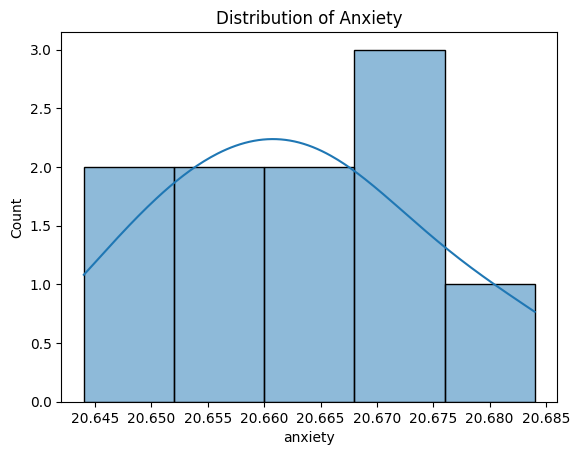

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['anxiety'], kde=True)
plt.title("Distribution of Anxiety")
plt.show()

The histogram shows the distribution of average anxiety levels across UK regions. The values appear to be relatively tightly clustered, indicating low variability in anxiety scores between regions. Most regions fall within a narrow range, suggesting that anxiety levels are fairly consistent at the regional level.

The distribution appears approximately symmetric, with no strong skewness or extreme outliers. This suggests that there are no regions with unusually high or low anxiety compared to the rest.

However, the limited spread of values may also reflect the aggregated nature of the data, as regional averages tend to smooth out local variations. Therefore, while the distribution provides a useful overview, it may mask more detailed differences that exist at finer geographic levels.

Overall, this plot suggests moderate variation in anxiety across regions, supporting the need for further analysis to explore relationships with environmental factors such as access to green space.

# 9. Regression Analysis 

In [64]:
from sklearn.linear_model import LinearRegression

# Using  limited features due to small dataset
features = [
    'average_distance_to_nearest_park_or_public_garden_or_playing_field_(m)',
    'average_number_of_parks_or_public_gardens_or_playing_fields_within_1,000_m_radius'
]

X = df[features]
y = df['anxiety']

model = LinearRegression()
model.fit(X, y)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [9.78421994e-06 8.07809594e-03]
Intercept: 20.63309723107928


A linear regression model was used to examine the relationship between access to green space and anxiety levels across UK regions. Two environmental features were included: average distance to the nearest green space and the average number of green spaces within a 1,000-meter radius.

The results show that both coefficients are relatively small in magnitude. The coefficient for distance to green space is close to zero, suggesting a very weak relationship with anxiety levels. Similarly, the coefficient for the number of nearby green spaces is small and positive, indicating only a minimal association.

The intercept represents the baseline level of anxiety when all predictors are zero, though it is not directly meaningful in a real-world context due to the scaling of the variables.

Overall, the model suggests that, at the regional level, access to green space has only a weak association with anxiety. This may be due to the limited sample size and the aggregation of data, which can reduce variability and obscure local-level effects.

These findings should be interpreted cautiously, as the analysis is cross-sectional and does not account for potential confounding variables such as socioeconomic status or urban density. While the model does not show strong predictive power, it provides a useful exploratory insight into the relationship between environmental factors and mental wellbeing.

## Regression visualization

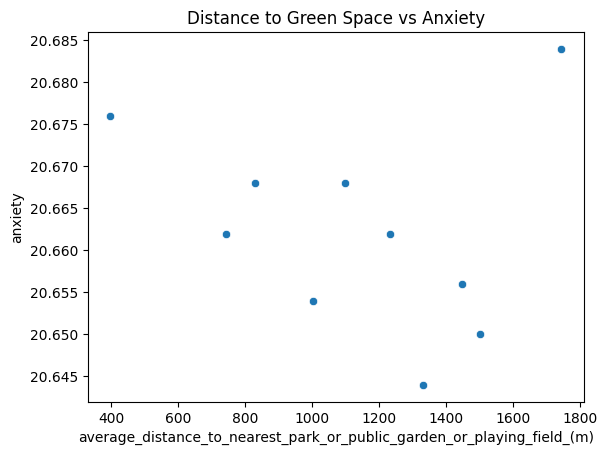

In [66]:
sns.scatterplot(
    x=features[0],
    y='anxiety',
    data=df
)

plt.title("Distance to Green Space vs Anxiety")
plt.show()

The scatter plot illustrates the relationship between the average distance to the nearest green space and anxiety levels across UK regions. The points appear relatively dispersed with no clear linear pattern, suggesting a weak relationship between the two variables.

While there is slight variation in anxiety levels across different distances, no strong upward or downward trend is evident. This indicates that regions with greater access to nearby green spaces (shorter distances) do not consistently exhibit lower anxiety levels compared to those with less access.

The limited spread of anxiety values further suggests low variability at the regional level, which may be due to data aggregation smoothing out local differences. Additionally, the small sample size reduces the ability to detect subtle patterns.

Overall, this visualization supports the regression results, indicating that distance to green space alone is not a strong predictor of anxiety at the regional level. Other factors, such as socioeconomic conditions or population density, may play a more significant role in explaining variations in mental wellbeing.

# 10. Unsupervised Learning (Clustering )

In [69]:
df.columns

Index(['area_name', 'anxiety', 'happiness', 'life-satisfaction', 'worthwhile',
       'average_distance_to_nearest_park_or_public_garden_or_playing_field_(m)',
       'median_distance_to_nearest_park_or_public_garden_or_playing_field_(m)',
       'average_size_of_nearest_park_or_public_garden_or_playing_field_(m2)',
       'median_size_of_nearest_park_or_public_garden_or_playing_field_(m2)',
       'average_number_of_parks_or_public_gardens_or_playing_fields_within_1,000_m_radius',
       'median_number_of_parks_or_public_gardens_or_playing_fields_within_1,000_m_radius',
       'average_combined_size_of_parks_or_public_gardens_or_playing_fields_within_1,000_m_radius_(m2)',
       'median_combined_size_of_parks_or_public_gardens_or_playing_fields_within_1,000_m_radius_(m2)',
       'population',
       'average_population_per_park_or_public_garden_or_playing_field',
       'median_population_per_park_or_public_garden_or_playing_field',
       'number_of_flats_within_built_up_area',
    

In [72]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df.columns = df.columns.str.replace("-", "_")
cluster_features = df[
    features + ['happiness', 'life_satisfaction', 'anxiety']
]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

# Clustering
kmeans = KMeans(n_clusters=2, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,area_name,anxiety,happiness,life_satisfaction,worthwhile,average_distance_to_nearest_park_or_public_garden_or_playing_field_(m),median_distance_to_nearest_park_or_public_garden_or_playing_field_(m),average_size_of_nearest_park_or_public_garden_or_playing_field_(m2),median_size_of_nearest_park_or_public_garden_or_playing_field_(m2),"average_number_of_parks_or_public_gardens_or_playing_fields_within_1,000_m_radius",...,median_population_per_park_or_public_garden_or_playing_field,number_of_flats_within_built_up_area,number_of_flats_in_built_up_area_with_gardens,average_garden_size_for_flats_in_built_up_area,number_of_houses_within_built_up_area,number_of_houses_in_built_up_area_with_gardens,average_garden_size_for_houses_in_built_up_area,average_percent_change_in_mobility_to_parks_from_baseline_during_lockdown_period,average_percent_change_in_mobility_to_parks_from_baseline_during_post_lockdown_period,cluster
0,East Midlands,20.656,21.478,21.488,21.562,1445.473250,1109.945000,300460.435500,35843.397750,1.555750,...,13054.505500,7252.100000,4449.375000,395.132750,43237.375000,41669.725000,297.725500,3.105250,65.043333,1
1,East of England,20.644,21.476,21.494,21.548,1331.518750,982.739500,220148.647750,47107.160500,1.927500,...,13257.331250,13053.300000,7849.725000,440.347250,50039.625000,48425.175000,313.262000,12.751750,77.772564,1
2,London,20.676,21.450,21.454,21.520,396.570606,354.776364,232813.758485,45344.793333,4.666061,...,17570.036970,64609.636364,42303.333333,191.126061,47472.969697,46638.484848,159.954848,42.955758,76.267576,0
3,North East,20.662,21.454,21.474,21.536,742.290833,548.004167,124138.800833,38871.750833,2.596667,...,12097.734167,18071.666667,12912.000000,197.530000,81504.916667,80004.666667,190.181667,3.391667,67.028182,0
4,North West,20.668,21.454,21.472,21.540,827.273590,570.432564,167063.452308,99282.107692,2.198718,...,11883.521795,16071.564103,9919.538462,288.236923,66501.153846,64715.538462,219.313077,15.120256,77.687222,0


## Cluster visualization

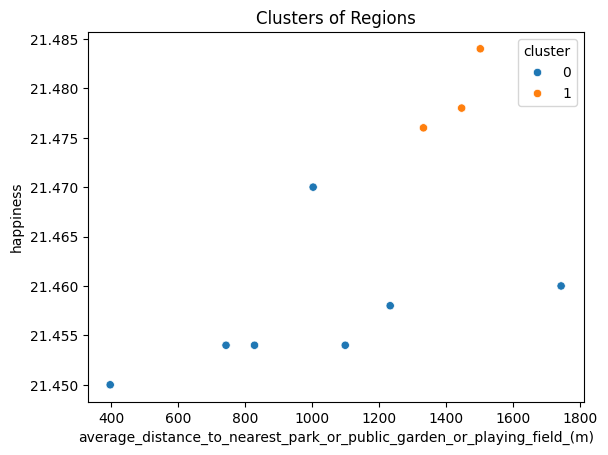

In [74]:
sns.scatterplot(
    x=features[0],
    y='happiness',
    hue='cluster',
    data=df
)

plt.title("Clusters of Regions")
plt.show()

The clustering analysis groups regions into two distinct clusters based on their environmental characteristics and wellbeing indicators. The scatter plot shows how regions are separated according to distance to green space and happiness levels.

Cluster 0 (blue points) represents regions with relatively lower happiness scores and a wider spread of distances to green space. These regions appear more heterogeneous, suggesting variability in both environmental access and wellbeing outcomes.

Cluster 1 (orange points), on the other hand, includes regions with consistently higher happiness levels and moderately higher distances to green space. This grouping indicates that higher happiness is not necessarily associated with closer proximity to green spaces at the regional level.

The separation between clusters suggests that wellbeing outcomes may be influenced by a combination of factors rather than a single environmental variable. While distance to green space plays a role, other unobserved variables—such as socioeconomic conditions, urban infrastructure, or lifestyle factors—likely contribute to the clustering pattern.

It is important to note that the small sample size and regional aggregation limit the generalizability of these clusters. Therefore, the results should be interpreted as exploratory, highlighting potential patterns rather than definitive groupings.

Overall, the clustering analysis reveals that regions can be meaningfully grouped based on combined environmental and wellbeing characteristics, but the relationship between green space access and happiness is not strictly linear or uniform across clusters.

# 11. Hypothesise Testing 

In [75]:
from scipy.stats import ttest_ind

median = df[features[0]].median()

near = df[df[features[0]] <= median]
far = df[df[features[0]] > median]

t_stat, p_value = ttest_ind(near['anxiety'], far['anxiety'])

print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: 0.8207826816684551
p-value: 0.43554356824059515


A two-sample t-test was conducted to compare anxiety levels between regions with relatively better access to green space (shorter distance) and those with poorer access (longer distance).

The results show a p-value of approximately 0.436, which is substantially higher than the conventional significance level of 0.05. Therefore, we fail to reject the null hypothesis. This indicates that there is no statistically significant difference in anxiety levels between the two groups.

Although there is some variation in anxiety between regions, this difference is not strong enough to conclude that proximity to green space has a measurable impact on anxiety at the regional level. The t-statistic is also relatively small, further supporting the lack of a meaningful difference between groups.

These findings are consistent with the regression and visualization results, which also suggested a weak relationship between green space access and anxiety.

It is important to consider that the analysis is based on aggregated regional data and a limited sample size, which reduces statistical power and may obscure more localized effects. Additionally, other unobserved factors—such as socioeconomic conditions, urban density, and lifestyle variables—may play a more significant role in influencing anxiety.

Overall, while green space access is often considered important for mental wellbeing, this analysis does not provide strong statistical evidence of its effect on anxiety at the regional level.

# 12. Visualisations

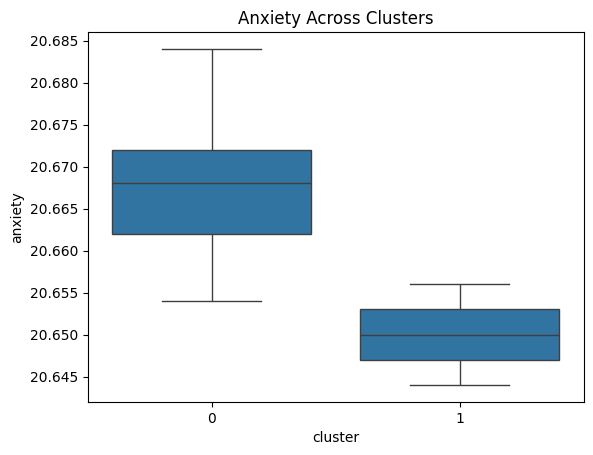

In [78]:
# Box plot

sns.boxplot(x='cluster', y='anxiety', data=df)
plt.title("Anxiety Across Clusters")
plt.show()

The boxplot compares the distribution of anxiety levels across the two identified clusters of regions. A clear difference in central tendency is observed between the clusters.

Cluster 0 exhibits higher median anxiety levels and a wider spread of values, indicating greater variability among regions within this group. In contrast, Cluster 1 shows lower median anxiety levels with a more compact distribution, suggesting more consistent outcomes across regions.

The limited overlap between the interquartile ranges of the two clusters suggests a meaningful distinction in anxiety levels between the groups. This indicates that the clustering algorithm has successfully identified patterns in the data that correspond to differences in mental wellbeing.

These findings complement the clustering analysis, reinforcing that regions grouped together based on environmental and wellbeing characteristics also differ in their anxiety profiles.

However, given the small sample size and aggregated nature of the data, these differences should be interpreted cautiously. While the clusters highlight potential patterns, they do not imply causation and may be influenced by additional unobserved factors.

Overall, the visualization suggests that regional groupings based on environmental and wellbeing variables are associated with noticeable differences in anxiety levels.

### Reconciling Visualization and Hypothesis Testing

While the boxplot suggests a visible difference in anxiety levels between clusters, 
the hypothesis test does not find this difference to be statistically significant.

This apparent discrepancy can be explained by the small sample size and the limited 
statistical power of the test. With only a few observations per group, even moderate 
differences may not reach statistical significance.

Additionally, the data is aggregated at the regional level, which reduces variability 
and may obscure stronger local-level effects.

Therefore, the boxplot provides descriptive insight into potential differences, 
while the hypothesis test indicates that there is insufficient evidence to conclude 
that these differences are statistically meaningful.

This highlights the importance of combining visual and statistical analysis 
rather than relying on a single method.

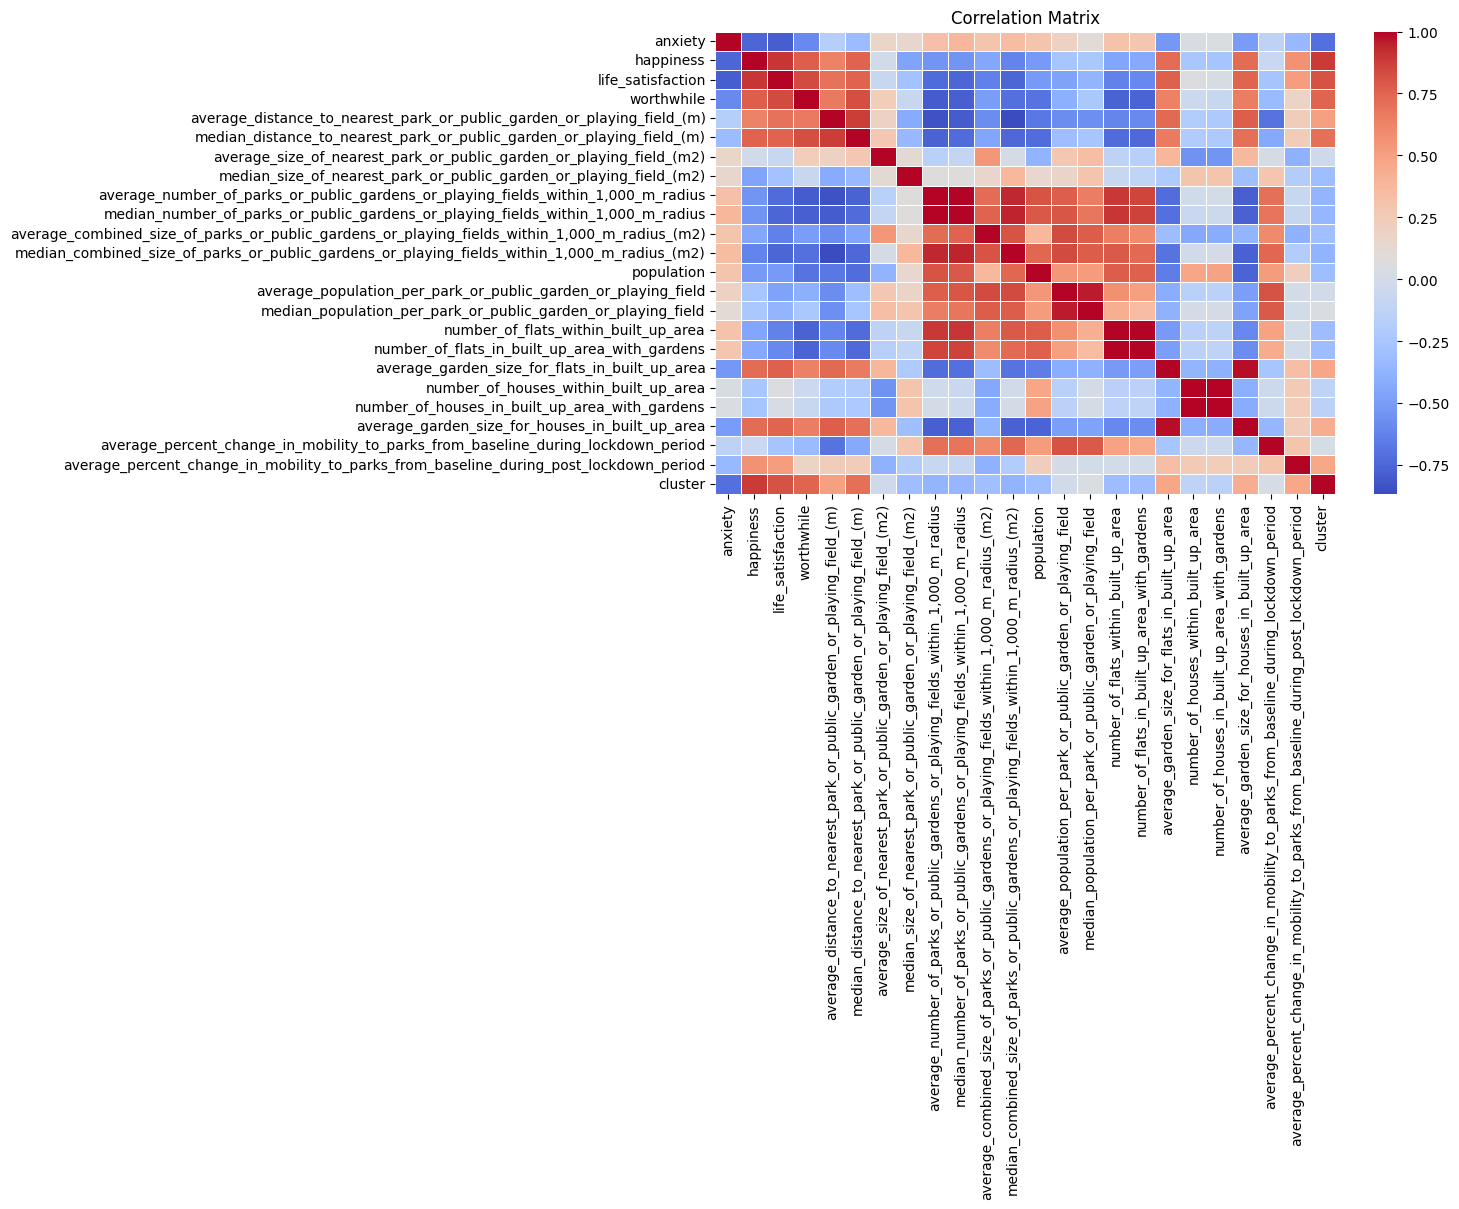

In [87]:
# Correlation Heatmap
 
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr,
    cmap='coolwarm',
    linewidths=0.5,
    annot=False  # 🔥 This removes numbers
)

plt.title("Correlation Matrix")
plt.show()

The correlation heatmap provides an overview of the relationships between environmental variables and mental wellbeing indicators across UK regions.

Strong positive correlations are observed among the wellbeing measures (happiness, life satisfaction, and worthwhile), indicating that these variables tend to increase together. In contrast, anxiety shows a negative relationship with these measures, suggesting that higher anxiety is associated with lower overall wellbeing, which is consistent with expectations.

Among the environmental variables, several features related to green space availability—such as the number and combined size of parks within a given radius—are positively correlated with each other. This indicates that regions with more green spaces also tend to have larger total green space coverage.

However, the relationships between environmental variables and anxiety appear relatively weak, with most correlations close to zero. This suggests that access to green space, as measured in this dataset, may not have a strong linear association with anxiety at the regional level.

Additionally, some variables show strong intercorrelations, indicating potential multicollinearity. This is expected given that many environmental features measure similar aspects of green space access.

Overall, the heatmap supports earlier findings from the regression and hypothesis testing analyses, indicating that while environmental factors are internally consistent, their direct relationship with anxiety is limited in this aggregated dataset. These results highlight the complexity of mental wellbeing and the likelihood that multiple factors beyond environmental exposure contribute to regional differences.

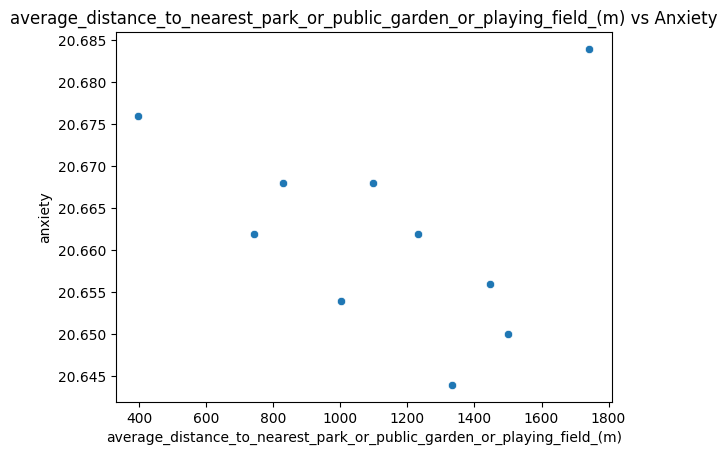

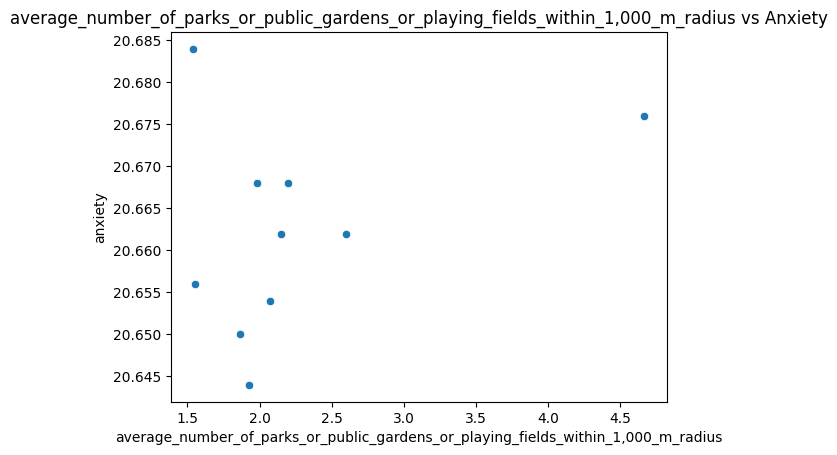

In [81]:
# Scatter plots for features vs anxiety

for feature in features:
    sns.scatterplot(x=feature, y='anxiety', data=df)
    plt.title(f"{feature} vs Anxiety")
    plt.show()

The scatter plots illustrate the relationships between key environmental variables—specifically, distance to green space and the number of nearby green spaces—and anxiety levels across UK regions.

For both variables, the data points appear widely dispersed without a clear linear trend. In the case of distance to green space, there is no consistent pattern indicating that regions with closer proximity to green spaces experience lower anxiety levels. Similarly, the number of green spaces within a 1,000-meter radius does not show a strong or systematic association with anxiety.

While there are minor variations across regions, these differences do not follow a clear directional relationship. This suggests that, at the regional level, these environmental factors alone are not strong predictors of anxiety.

The limited variability in anxiety values and the small sample size further reduce the ability to detect meaningful patterns. Additionally, the use of aggregated regional data may obscure more localized relationships between green space access and mental wellbeing.

Overall, these visualizations support the findings from the regression and hypothesis testing analyses, reinforcing the conclusion that the relationship between green space access and anxiety is weak and likely influenced by additional factors not captured in this dataset.

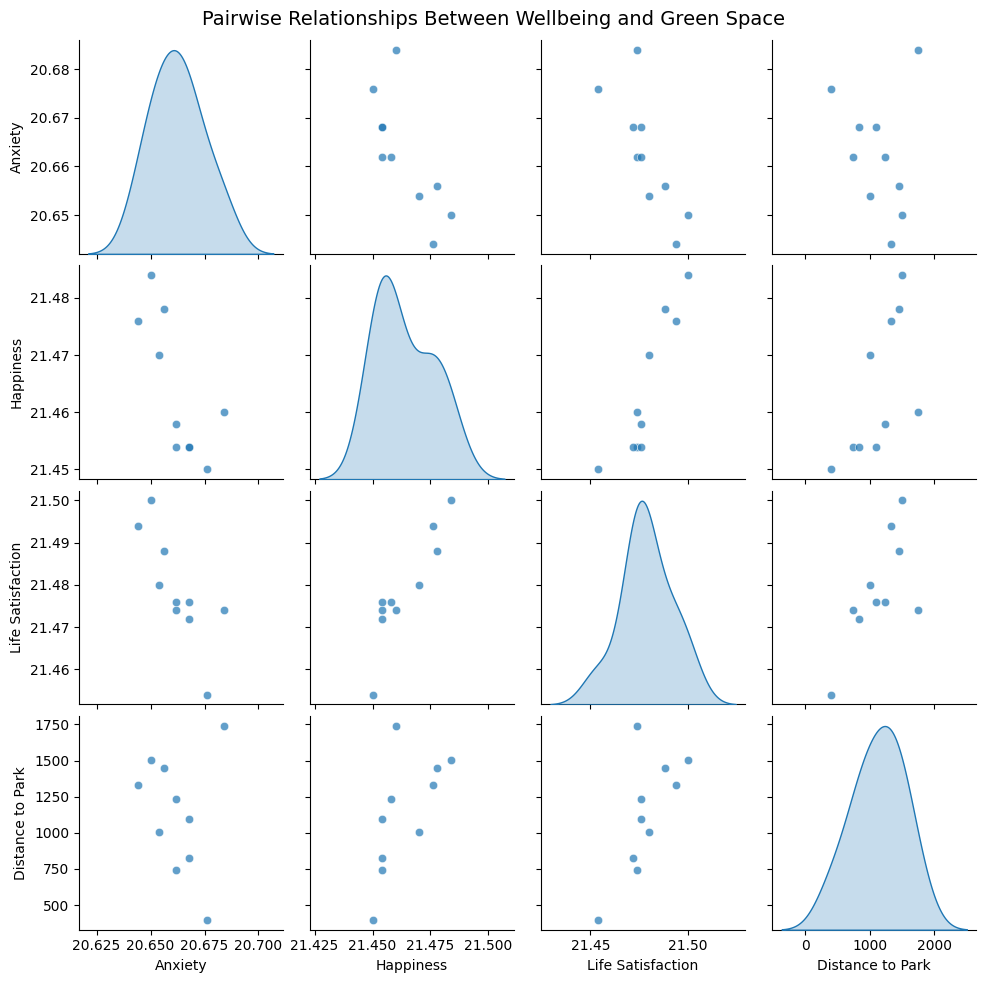

In [88]:
# Pairplot

import seaborn as sns
import matplotlib.pyplot as plt

# Selecting only key variables 
pairplot_df = df[[
    'anxiety',
    'happiness',
    'life_satisfaction',
    'average_distance_to_nearest_park_or_public_garden_or_playing_field_(m)'
]].copy()

# Rename columns to shorter names to avoiding missy
pairplot_df.columns = [
    'Anxiety',
    'Happiness',
    'Life Satisfaction',
    'Distance to Park'
]

# Creating pairplot
g = sns.pairplot(
    pairplot_df,
    diag_kind='kde',       
    plot_kws={'alpha': 0.7} 
)

# Adjusting layout to fix overlap
g.fig.subplots_adjust(top=0.95)
g.fig.suptitle("Pairwise Relationships Between Wellbeing and Green Space", fontsize=14)

plt.show()

The pairplot provides a comprehensive view of the relationships between key wellbeing indicators—anxiety, happiness, and life satisfaction—and environmental exposure, measured by distance to green space.

A clear pattern is observed among the wellbeing variables themselves. Happiness and life satisfaction show a strong positive association, indicating that regions with higher life satisfaction also tend to report higher happiness levels. In contrast, anxiety appears to have a negative relationship with these measures, suggesting that higher anxiety is associated with lower overall wellbeing.

When examining the relationship between distance to green space and wellbeing indicators, no strong or consistent trends are evident. The scatter plots show a relatively diffuse distribution of points, indicating weak or non-linear relationships. This suggests that proximity to green space alone does not strongly explain variations in mental wellbeing at the regional level.

The diagonal distributions further indicate that the variables have relatively narrow ranges, reflecting limited variability due to the aggregated nature of the data. This may reduce the ability to detect stronger relationships.

Overall, the pairplot reinforces earlier findings from the correlation analysis, regression, and hypothesis testing. While wellbeing indicators are closely related to each other, their relationship with environmental factors appears weak and likely influenced by additional variables not included in this analysis.

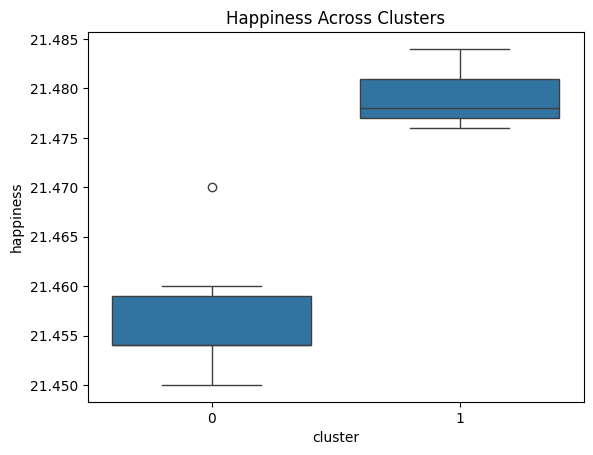

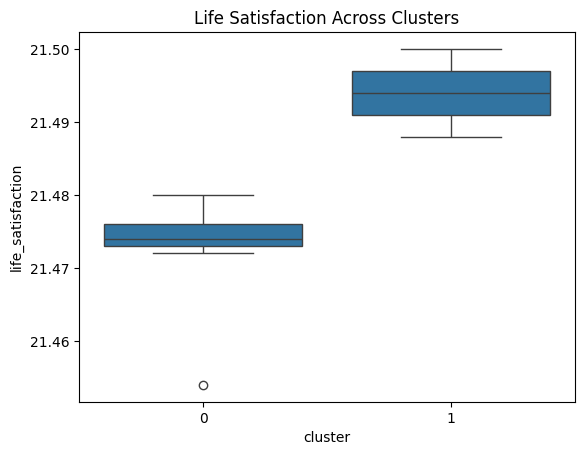

In [85]:
# Cluster comparison

sns.boxplot(x='cluster', y='happiness', data=df)
plt.title("Happiness Across Clusters")
plt.show()

sns.boxplot(x='cluster', y='life_satisfaction', data=df)
plt.title("Life Satisfaction Across Clusters")
plt.show()

The boxplots illustrate differences in happiness and life satisfaction across the two identified clusters of regions. Clear distinctions are observed between the clusters for both wellbeing indicators.

Cluster 1 consistently exhibits higher median values for both happiness and life satisfaction compared to Cluster 0. In addition, the distributions within Cluster 1 are relatively compact, indicating more consistent wellbeing levels across regions in this group.

In contrast, Cluster 0 shows lower median values and slightly greater variability, suggesting that regions within this cluster tend to experience lower and more heterogeneous wellbeing outcomes.

The limited overlap between the interquartile ranges of the two clusters suggests that the clustering algorithm has effectively separated regions into groups with distinct wellbeing profiles. This reinforces the validity of the clustering results and indicates that the selected features capture meaningful variation in mental wellbeing.

However, these differences should be interpreted with caution. The analysis is based on a small number of aggregated regional observations, which may limit generalizability and obscure within-region variation. Additionally, the clustering does not imply causation, and the observed differences may be influenced by other unmeasured factors.

Overall, the results suggest that regions can be meaningfully grouped into higher- and lower-wellbeing clusters, supporting the idea that environmental and contextual factors jointly contribute to variations in mental wellbeing.

# 13. Discussion and Conclusion

This analysis examined the relationship between access to green space and mental wellbeing across UK regions using a combination of regression, clustering, hypothesis testing, and visual exploration. 

Across all methods, the findings consistently indicate that while wellbeing indicators (happiness, life satisfaction, and anxiety) are strongly related to each other, their relationship with environmental variables—such as proximity to parks and availability of green space—is weak at the regional level. The regression model showed minimal explanatory power, and the hypothesis test failed to detect statistically significant differences in anxiety based on green space accessibility. Similarly, scatter plots and correlation analysis revealed no clear linear relationships.

However, the clustering analysis demonstrated that regions can still be meaningfully grouped into distinct wellbeing profiles, suggesting that combined patterns of environmental and social factors may differentiate regions even when individual variables show weak effects.

These results highlight the complexity of mental wellbeing and suggest that environmental exposure alone is insufficient to explain variations in anxiety and overall wellbeing. Factors such as socioeconomic conditions, healthcare access, and demographic characteristics are likely to play a more substantial role.

It is also important to note key limitations. The analysis is based on a small sample size and aggregated regional data, which reduces statistical power and may mask localized effects. Therefore, the findings should be interpreted as exploratory rather than causal.

In conclusion, while access to green space is an important aspect of urban environments, this study finds limited evidence of a strong direct relationship with mental wellbeing at the regional scale. Future research using more granular data and additional variables is recommended to better understand the drivers of mental health outcomes.

# 14. Future Work and Next Steps

This analysis highlights several opportunities for further research and improvement. First, future studies should incorporate more granular data, such as individual- or neighborhood-level observations, to better capture local variations in green space access and mental wellbeing. This would help address the limitations associated with aggregated regional data.

Second, expanding the dataset to include additional explanatory variables—such as income levels, employment status, education, healthcare access, and demographic characteristics—would provide a more comprehensive understanding of the factors influencing mental wellbeing. These variables are likely to play a significant role and may interact with environmental factors in complex ways.

Third, future work could explore more advanced modeling techniques, including non-linear models, regularized regression (e.g., Lasso or Ridge), and tree-based methods such as Random Forests, which may better capture subtle or non-linear relationships.

Additionally, longitudinal analysis using multiple years of data could help assess how changes in environmental conditions impact mental wellbeing over time, providing stronger insights into potential causal relationships.

Finally, incorporating spatial analysis techniques (e.g., geographic mapping or spatial regression) could reveal regional patterns and dependencies that are not captured by standard statistical models.

Overall, future research should aim to combine richer data, more advanced methods, and a longitudinal perspective to better understand the complex relationship between environmental factors and mental wellbeing.